# M0 - Baseline regression lineaire (5 variables)

Objectif:
- entrainer une baseline lineaire sur `train.csv`
- utiliser uniquement les 5 variables retenues dans l'analyse (et recommandées par le prof)


Variables retenues:
`['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood']`


In [1]:
from pathlib import Path

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve
from sklearn.impute import KNNImputer
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import cross_validate
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats



# Pour le VIF (installé si nécessaire)
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant
    VIF_AVAILABLE = True
except ImportError:
    print("statsmodels non disponible - analyse VIF skip")
    VIF_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Fonction utilitaire RMSE (utilisée comme scorer dans la validation croisée)
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 1. CHARGEMENT DES DONNÉES ET PRÉPARATION DE LA TARGET
- On charge les fichiers `train.csv`, `test.csv` et `sample_submission.csv` depuis le dossier `Data/`.
- On crée la variable `AgeAtSale = YrSold - YearBuilt` : l'âge de la maison au moment de la vente. On préfère cette variable dérivée à `YearBuilt` brut car elle capture directement l'effet de vieillissement sur le prix (une maison de 50 ans vendue en 2010 et une maison de 50 ans vendue en 2006 ont le même âge, mais pas la même année de construction).
- On définit les 5 variables d'entrée (features) retenues lors de l'analyse exploratoire, ainsi que la variable cible (`SalePrice`).

In [2]:
# Chargement des donnees
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "Data"

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"train shape: {train_df.shape}")
print(f"test shape: {test_df.shape}")
print(f"sample_submission shape: {sample_submission.shape}")

# Feature engineering: AgeAtSale = annee de vente - annee de construction
for df in [train_df, test_df]:
    df["AgeAtSale"] = df["YrSold"] - df["YearBuilt"]

features = ["OverallQual", "GrLivArea", "TotalBsmtSF", "AgeAtSale", "Neighborhood"]
target = "SalePrice"

print("Features baseline:", features)


train shape: (1460, 81)
test shape: (1459, 80)
sample_submission shape: (1459, 2)
Features baseline: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'AgeAtSale', 'Neighborhood']


## 2. Détection exploratoire des outliers (Méthode IQR)
- On utilise la méthode IQR (Interquartile Range) pour détecter automatiquement les valeurs aberrantes sur les variables de surface (`GrLivArea`, `TotalBsmtSF`).
- Cette étape est **exploratoire** : on identifie et on visualise les outliers pour comprendre leur nature avant de décider lesquels supprimer.
- On prépare aussi une windsorisation (écrêtage) des surfaces pour comparer plus tard si cela améliore la baseline, en créant des colonnes `_winsorized` sans modifier les originales.

Détection des outliers (méthode IQR):

GrLivArea:
  Nombre d'outliers: 31 (2.12%)
  Bornes: [158.62, 2747.62]

TotalBsmtSF:
  Nombre d'outliers: 61 (4.18%)
  Bornes: [42.00, 2052.00]


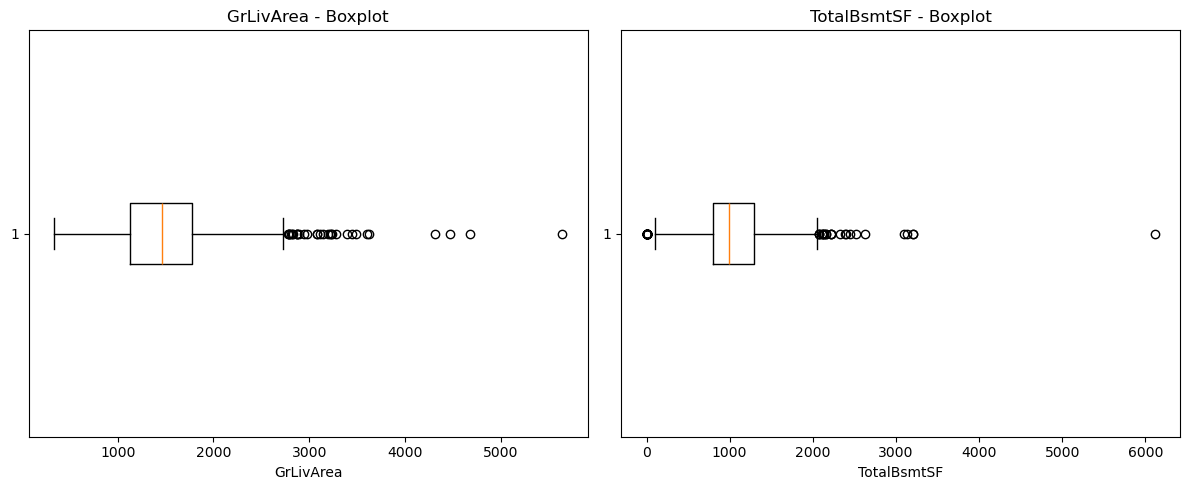


Variables winsorisées créées pour comparaison future.


In [3]:
# Détection des outliers sur les variables de surface
surface_vars = ['GrLivArea', 'TotalBsmtSF']

def detect_outliers_iqr(df, variables, threshold=1.5):
    """Détection des outliers avec la méthode IQR"""
    outliers_info = {}

    for var in variables:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

        outliers_info[var] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_indices': outliers.index.tolist(),
        }

    return outliers_info

# Détection des outliers
outliers_info = detect_outliers_iqr(train_df, surface_vars)

print("Détection des outliers (méthode IQR):")
for var, info in outliers_info.items():
    print(f"\n{var}:")
    print(f"  Nombre d'outliers: {info['count']} ({info['percentage']:.2f}%)")
    print(f"  Bornes: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")

# Visualisation des outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, var in enumerate(surface_vars):
    axes[i].boxplot(train_df[var].dropna(), vert=False)
    axes[i].set_title(f'{var} - Boxplot')
    axes[i].set_xlabel(var)

plt.tight_layout()
plt.show()

# Option: Winsorisation (remplacer les outliers par les bornes)
def winsorize_series(series, lower_bound, upper_bound):
    return series.clip(lower_bound, upper_bound)

# Création de versions winsorisées pour comparaison éventuelle
train_df_winsorized = train_df.copy()
for var in surface_vars:
    info = outliers_info[var]
    train_df_winsorized[f'{var}_winsorized'] = winsorize_series(
        train_df[var], info['lower_bound'], info['upper_bound']
    )

print("\nVariables winsorisées créées pour comparaison future.")

# 3. Nettoyage des outliers critiques (Recommandation de la documentation)

- On automatise la détection des outliers critiques : les maisons avec une surface habitable énorme (>4000 sqft) mais un prix étonnamment bas (<300k $). Ces points sont suspects et peuvent fausser la baseline linéaire.
- On les supprime du train set, mais on garde les grandes maisons très chères (ce sont de vrais manoirs, pas des erreurs de données).

--- Analyse IQR Initiale ---
GrLivArea: 31 outliers détectés (2.12%)
TotalBsmtSF: 61 outliers détectés (4.18%)


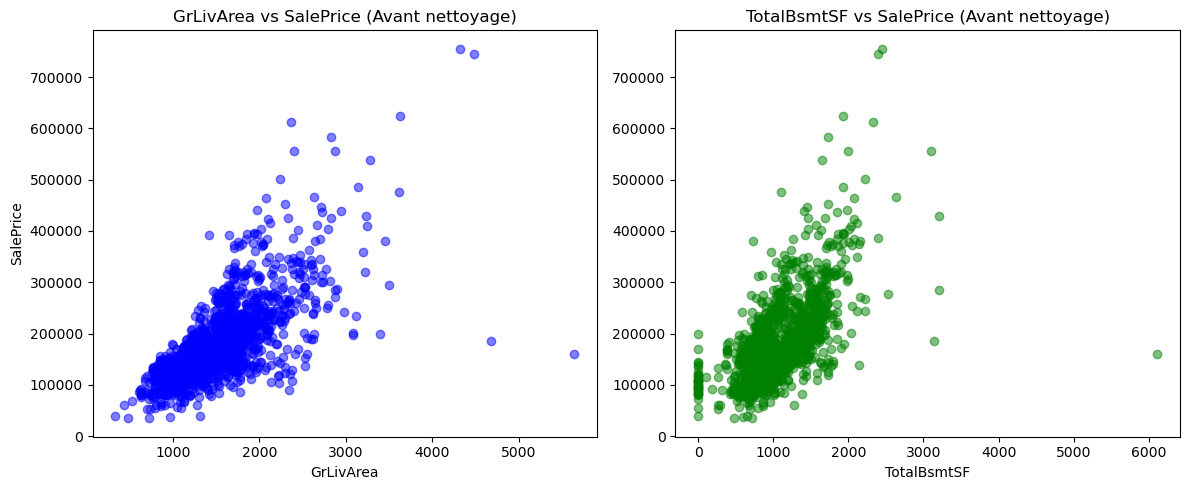


--- Nettoyage ---
Nombre d'outliers critiques supprimés (Surface énorme, prix bas) : 2
Nouveau shape du train set : (1458, 82)


In [4]:
surface_vars = ['GrLivArea', 'TotalBsmtSF']


def detect_outliers_iqr(df, variables, threshold=1.5):
    """Détection des outliers avec la méthode IQR"""
    outliers_info = {}

    for var in variables:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]

        outliers_info[var] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
        }

    return outliers_info


outliers_info = detect_outliers_iqr(train_df, surface_vars)

print("--- Analyse IQR Initiale ---")
for var, info in outliers_info.items():
    print(f"{var}: {info['count']} outliers détectés ({info['percentage']:.2f}%)")

# 2. Visualisation avant nettoyage (Scatter plot : Surface vs Prix)
# C'est LE graphique qui permet de comprendre pourquoi on supprime ces points
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(train_df['GrLivArea'], train_df['SalePrice'], alpha=0.5, color='blue')
axes[0].set_title('GrLivArea vs SalePrice (Avant nettoyage)')
axes[0].set_xlabel('GrLivArea')
axes[0].set_ylabel('SalePrice')

axes[1].scatter(train_df['TotalBsmtSF'], train_df['SalePrice'], alpha=0.5, color='green')
axes[1].set_title('TotalBsmtSF vs SalePrice (Avant nettoyage)')
axes[1].set_xlabel('TotalBsmtSF')

plt.tight_layout()
plt.show()

# 3. SUPPRESSION CIBLÉE (Recommandation de la documentation)
# On supprime les maisons énormes (>4000 sqft) mais étonnamment peu chères.
# On évite de supprimer les maisons >4000 sqft qui SONT très chères (ce sont de vrais manoirs).

condition_aberrante = (train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)
outliers_a_supprimer = train_df[condition_aberrante]

print(f"\n--- Nettoyage ---")
print(f"Nombre d'outliers critiques supprimés (Surface énorme, prix bas) : {len(outliers_a_supprimer)}")

# On met à jour le dataframe d'entraînement
train_df = train_df.drop(outliers_a_supprimer.index).reset_index(drop=True)

print(f"Nouveau shape du train set : {train_df.shape}")

# Optionnel : Tu pourrais refaire un nuage de points ici pour montrer que les "points en bas à droite" ont disparu.

# 4. Vérification des valeurs manquantes
- Avant de construire le pipeline, on vérifie le taux de valeurs manquantes pour chacune des 5 variables retenues, à la fois sur le train et le test.
- C'est une étape indispensable car certaines méthodes d'imputation (comme le `KNNImputer`) se comportent différemment selon le taux de données manquantes. Si une variable a trop de NaN, il vaut mieux la traiter différemment (ex: imputation par 0 pour `TotalBsmtSF` quand il n'y a pas de sous-sol).
- On constate ici que seule `TotalBsmtSF` présente des valeurs manquantes dans le test set, ce qui justifie son traitement séparé dans le pipeline (imputation par 0).

In [5]:
missing_train = train_df[features].isna().mean().mul(100).sort_values(ascending=False)
missing_test = test_df[features].isna().mean().mul(100).sort_values(ascending=False)

print("Missing % (train):")
print(missing_train)
print("\nMissing % (test):")
print(missing_test)


Missing % (train):
OverallQual     0.0
GrLivArea       0.0
TotalBsmtSF     0.0
AgeAtSale       0.0
Neighborhood    0.0
dtype: float64

Missing % (test):
TotalBsmtSF     0.06854
OverallQual     0.00000
GrLivArea       0.00000
AgeAtSale       0.00000
Neighborhood    0.00000
dtype: float64


# 5. Séparation X / y
- On sépare les données en variables explicatives (`X_train`, `X_test`) et variable cible (`y_train`).
- On crée également `y_train_log = log1p(SalePrice)` : la transformation logarithmique de la cible. Deux raisons à cela :
    1. **Distribution** : `SalePrice` a une distribution très asymétrique (beaucoup de maisons moyennes, quelques manoirs très chers). Le log la rend plus symétrique, ce qui facilite l'apprentissage d'un modèle linéaire.
    2. **Métrique Kaggle** : Le challenge évalue les soumissions sur le RMSLE (Root Mean Squared Log Error), ce qui revient à calculer le RMSE sur les prix en log. Entraîner le modèle directement sur `log1p(SalePrice)` optimise donc la métrique officielle.

In [6]:
# X / y
X_train = train_df[features].copy()
X_test = test_df[features].copy()

y_train = train_df[target].copy()
y_train_log = np.log1p(y_train)


# 6. Preprocessing Baseline
- KNNImputer pour les numériques : Consiste à remplacer les valeurs manquantes par la moyenne des k voisins les plus proches. (suite à des tests avec la version plus simple de SimpleImputer, le KNNImputer a montré une légère amélioration du RMSE en validation croisée.
- TargetEncoder pour les catégorielles : Consiste à remplacer les catégories par la moyenne de la cible pour chaque catégorie, avec un lissage pour éviter les fuites de données. (C'est plus performant que le OneHotEncoder pour les modèles linéaires sur ce dataset, car il capture mieux l'impact de chaque quartier sur le prix).
- StandardScaler pour tout le monde : Pour que les coefficients de la régression linéaire soient sur la même échelle et plus interprétables. (C'est une bonne pratique pour les modèles linéaires, même si ça n'améliore pas toujours le RMSE, ça rend l'analyse des coefficients plus claire).

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Groupes de colonnes (Toujours tes 5 variables strictes en entrée)
num_features = ["OverallQual", "GrLivArea", "AgeAtSale"]
num_zero_features = ["TotalBsmtSF"]
cat_features = ["Neighborhood"]

# 1. Pipeline Numérique (L'évolution polynomiale est ici !)
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    # C'est ici ! degree=2 met au carré et crée les interactions. include_bias=False évite une colonne de 1 inutiles.
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# 2. Pipeline "Zéro" (On peut aussi lui ajouter le poly si on veut le sous-sol au carré)
zero_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), # Ajouté ici aussi
    ('scaler', StandardScaler())
])

# 3. Pipeline Catégorielle (Target Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(smoothing=10, handle_missing='value', handle_unknown='value')),
    ('scaler', StandardScaler())
])

# L'assembleur final
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('num_zero', zero_transformer, num_zero_features),
        ('cat', categorical_transformer, cat_features)
    ])

# Création du pipeline complet
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

print("Pipeline Baseline (Polynomial) créé avec succès !")

Pipeline Baseline (Polynomial) créé avec succès !


# 7. Évaluation de la Baseline (Validation Croisée 5-Fold)
- On évalue la baseline en validation croisée stratifiée sur 5 folds, en mesurant le RMSE sur l'échelle logarithmique (ce qui correspond exactement au RMSLE utilisé par Kaggle pour classer les soumissions).
- On compare les scores Train vs CV pour détecter l'overfitting : si le RMSE sur le train est beaucoup plus bas que sur la validation, c'est un signe que le modèle mémorise les données d'entraînement au lieu de généraliser.
- On mesure aussi le R² (coefficient de détermination) pour quantifier la part de variance du prix expliquée par le modèle.

In [8]:
print("Début de l'évaluation du modèle Baseline (Linear Regression)...")

# On définit les métriques que l'on veut observer
scoring = {
    'rmse_log': make_scorer(rmse, greater_is_better=False),
    'r2': 'r2'
}

# Lancement de la validation croisée sur le Pipeline complet
# On utilise y_train_log car le modèle doit prédire le log du prix
cv_results = cross_validate(
    baseline_pipeline,
    X_train,
    y_train_log,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

# Extraction et nettoyage des résultats
mean_rmse_cv = -cv_results['test_rmse_log'].mean()
std_rmse_cv = cv_results['test_rmse_log'].std()

mean_r2_cv = cv_results['test_r2'].mean()
std_r2_cv = cv_results['test_r2'].std()

print("\n--- RÉSULTATS DE LA VALIDATION CROISÉE (5-Fold) ---")
print(f"RMSE (Log Price)  : {mean_rmse_cv:.5f} (+/- {std_rmse_cv:.5f})")
print(f"R² Score          : {mean_r2_cv:.5f} (+/- {std_r2_cv:.5f})")

# Vérification de l'overfitting (Comparaison Train vs Test)
mean_rmse_train = -cv_results['train_rmse_log'].mean()
print(f"\nRMSE sur le Train : {mean_rmse_train:.5f}")
if (mean_rmse_cv - mean_rmse_train) > 0.02:
    print("⚠️ Attention : Le modèle semble faire de l'overfitting (Le score CV est nettement pire que le score Train).")
else:
    print("✅ Le modèle est stable : pas d'overfitting majeur détecté.")

Début de l'évaluation du modèle Baseline (Linear Regression)...

--- RÉSULTATS DE LA VALIDATION CROISÉE (5-Fold) ---
RMSE (Log Price)  : 0.15739 (+/- 0.00588)
R² Score          : 0.84327 (+/- 0.01976)

RMSE sur le Train : 0.15345
✅ Le modèle est stable : pas d'overfitting majeur détecté.


# 8. Entrainement final et interprétation des coefficients
- On entraîne le modèle sur 100% du train set pour obtenir les coefficients finaux en se basant sur l'étape précédente.
- Ajout d'un graph des coefficients avec des couleurs pour différencier les variables qui augmentent le prix (en vert) de celles qui le diminuent (en rouge). Pour comprendre rapidement l'impact de chaque variable sur le prix de vente, et identifier les leviers les plus puissants pour augmenter la valeur d'une maison (ex: améliorer la qualité globale, augmenter la surface habitable, etc.).

Entraînement du modèle Baseline sur 100% du Train Set...

Impact des variables pour la Baseline :


,Variable,Coefficient_Log
1,GrLivArea,0.148155
4,OverallQual GrLivArea,0.146192
9,TotalBsmtSF,0.114290
6,GrLivArea^2,-0.106004
2,AgeAtSale,-0.102620
11,Neighborhood,0.072492
5,OverallQual AgeAtSale,0.065838
10,TotalBsmtSF^2,-0.037530
0,OverallQual,0.036579
8,AgeAtSale^2,-0.033337


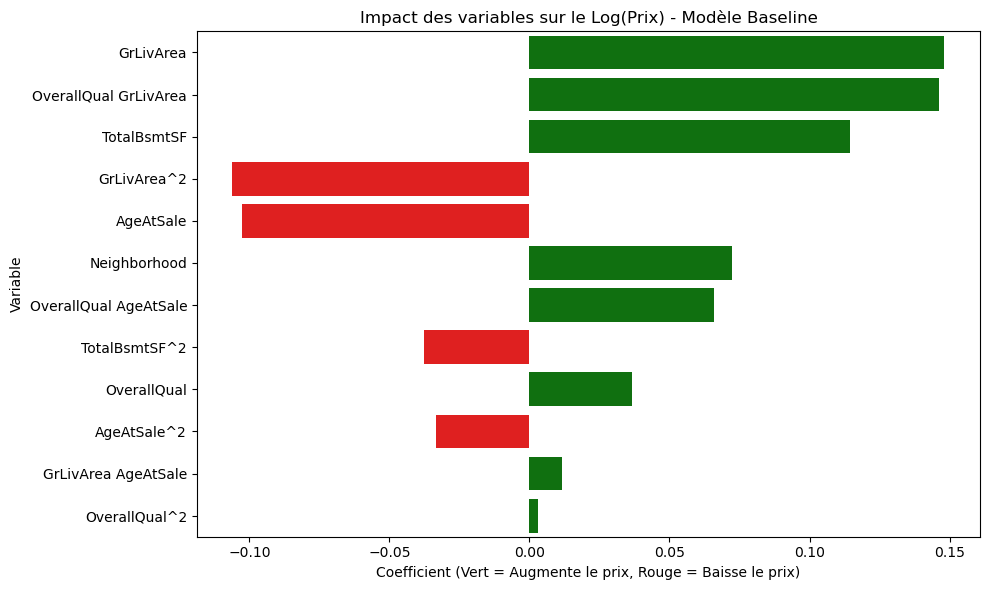


Génération du fichier de soumission Kaggle Baseline...
Fichier 'submission_baseline.csv' créé !


In [9]:
print("Entraînement du modèle Baseline sur 100% du Train Set...")
baseline_pipeline.fit(X_train, y_train_log)

# 1. Extraction dynamique des noms des colonnes
# On vérifie si tu utilises les PolynomialFeatures ou l'approche standard
num_transformer = baseline_pipeline.named_steps['preprocessor'].named_transformers_['num']

if 'poly' in num_transformer.named_steps:
    # Si utilisation de PolynomialFeatures (Noms complexes générés)
    num_cols = num_transformer.named_steps['poly'].get_feature_names_out(num_features).tolist()

    zero_transformer = baseline_pipeline.named_steps['preprocessor'].named_transformers_['num_zero']
    zero_cols = zero_transformer.named_steps['poly'].get_feature_names_out(num_zero_features).tolist()
else:
    # Si approche standard (5 variables strictes)
    num_cols = num_features
    zero_cols = num_zero_features

# Le TargetEncoder garde toujours le nom d'origine de la colonne
cat_cols = cat_features

all_feature_names = num_cols + zero_cols + cat_cols

# 2. Extraction des coefficients de la Régression Linéaire
coefficients = baseline_pipeline.named_steps['model'].coef_.flatten()

# 3. Création d'un tableau récapitulatif
coef_df = pd.DataFrame({
    'Variable': all_feature_names,
    'Coefficient_Log': coefficients
})

# Tri par l'impact absolu le plus fort
coef_df['Impact_Absolu'] = coef_df['Coefficient_Log'].abs()
coef_df = coef_df.sort_values(by='Impact_Absolu', ascending=False).drop(columns=['Impact_Absolu'])

print("\nImpact des variables pour la Baseline :")
display(coef_df.head(15))

# 4. Visualisation des coefficients
plt.figure(figsize=(10, 6))
top_coefs = coef_df.head(15)

# Création de la liste de couleurs
couleurs_barres = top_coefs['Coefficient_Log'].apply(lambda x: 'red' if x < 0 else 'green').tolist()

sns.barplot(
    data=top_coefs,
    x='Coefficient_Log',
    y='Variable',
    palette=couleurs_barres,
    hue='Variable',
    legend=False
)

plt.title('Impact des variables sur le Log(Prix) - Modèle Baseline')
plt.xlabel('Coefficient (Vert = Augmente le prix, Rouge = Baisse le prix)')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

# 5. SOUMISSION KAGGLE
print("\nGénération du fichier de soumission Kaggle Baseline...")
log_predictions = baseline_pipeline.predict(X_test)
final_predictions = np.expm1(log_predictions)

submission = pd.DataFrame({
    'Id': sample_submission['Id'],
    'SalePrice': final_predictions
})

submission.to_csv('submission_baseline.csv', index=False)
print("Fichier 'submission_baseline.csv' créé !")

# 9. Diagnostic : Courbes d'Apprentissage (Learning Curves)
- Les courbes d'apprentissage montrent comment évoluent les erreurs d'entraînement et de validation lorsqu'on augmente progressivement la taille du jeu de données.
- C'est un outil de diagnostic essentiel pour comprendre si le modèle souffre de :
    - **Biais élevé (underfitting)** : les deux courbes convergent vers une erreur élevée → le modèle est trop simple.
    - **Variance élevée (overfitting)** : un large écart persiste entre les courbes train et validation → le modèle mémorise le bruit.
    - **Bon compromis** : les deux courbes convergent vers une erreur faible avec un écart raisonnable.

Génération des courbes d'apprentissage (patiente quelques secondes)...


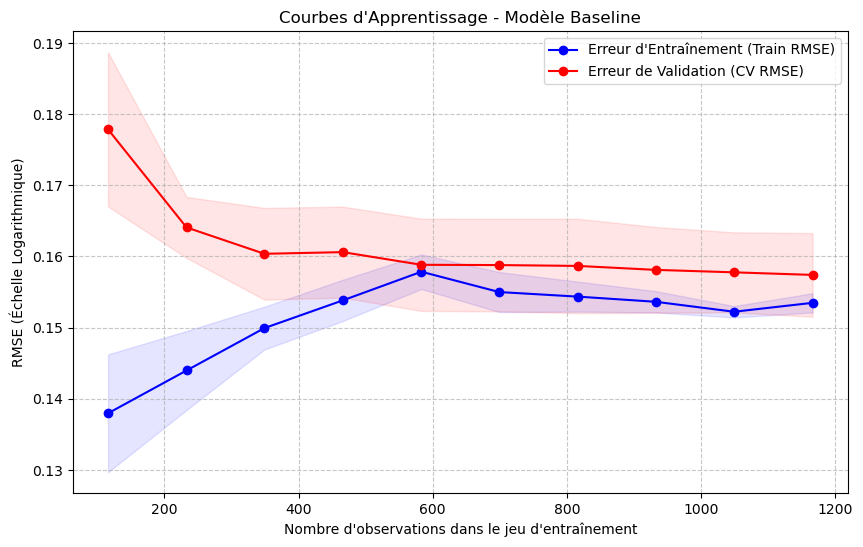


--- ANALYSE DU MODÈLE ---
Erreur Train finale : 0.1535
Erreur Val finale   : 0.1574
Écart (Gap)         : 0.0039
✅ Écart très faible : Excellente généralisation.
💡 Note : L'erreur globale est un peu haute. C'est de l'underfitting (typiquement attendu d'une Baseline).


In [10]:
def plot_learning_curves(pipeline, X, y, cv):
    print("Génération des courbes d'apprentissage (patiente quelques secondes)...")

    # On utilise le RMSE en log pour être cohérent avec l'évaluation Kaggle
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y, cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    # Conversion des scores négatifs en RMSE positif
    train_scores_mean = -train_scores.mean(axis=1)
    train_scores_std = train_scores.std(axis=1)
    val_scores_mean = -val_scores.mean(axis=1)
    val_scores_std = val_scores.std(axis=1)

    # Visualisation
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='blue', label='Erreur d\'Entraînement (Train RMSE)')
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='blue')

    plt.plot(train_sizes, val_scores_mean, 'o-', color='red', label='Erreur de Validation (CV RMSE)')
    plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color='red')

    plt.xlabel('Nombre d\'observations dans le jeu d\'entraînement')
    plt.ylabel('RMSE (Échelle Logarithmique)')
    plt.title('Courbes d\'Apprentissage - Modèle Baseline')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Analyse de l'écart final (Gap)
    final_train_error = train_scores_mean[-1]
    final_val_error = val_scores_mean[-1]
    final_gap = final_val_error - final_train_error

    print(f"\n--- ANALYSE DU MODÈLE ---")
    print(f"Erreur Train finale : {final_train_error:.4f}")
    print(f"Erreur Val finale   : {final_val_error:.4f}")
    print(f"Écart (Gap)         : {final_gap:.4f}")

    # Seuils adaptés à l'échelle logarithmique (RMSE Log)
    if final_gap > 0.05:
        print("⚠️ Écart important : Le modèle fait de l'overfitting (surapprentissage).")
    elif final_gap < 0.015:
        print("✅ Écart très faible : Excellente généralisation.")
        if final_train_error > 0.15:
             print("💡 Note : L'erreur globale est un peu haute. C'est de l'underfitting (typiquement attendu d'une Baseline).")
    else:
        print("📊 Écart modéré : Équilibre tout à fait acceptable.")

# Lancement sur notre Pipeline Baseline
plot_learning_curves(baseline_pipeline, X_train, y_train_log, cv=cv)

# 10. Analyse des résidus (Validation des hypothèses du modèle linéaire)
- On vérifie que les résidus sont bien centrés autour de zéro pour confirmer que le modèle ne fait pas d'erreurs systématiques (ex: sous-estimer les grandes maisons et surestimer les petites).
- On vérifie que les résidus ont une distribution normale (histogramme et QQ-plot) pour valider l'hypothèse d'erreur normale, ce qui est important pour l'interprétation des coefficients et la validité des tests statistiques associés à la régression linéaire.
- On trace aussi les résidus en fonction des prédictions pour vérifier l'homoscédasticité (variance constante des erreurs) : si le nuage de points forme un entonnoir, c'est le signe que le modèle est plus précis pour certaines gammes de prix que d'autres.

Analyse des résidus de la Baseline...
Moyenne des résidus : -0.0000 (Idéalement proche de 0)
Écart-type des résidus : 0.1533


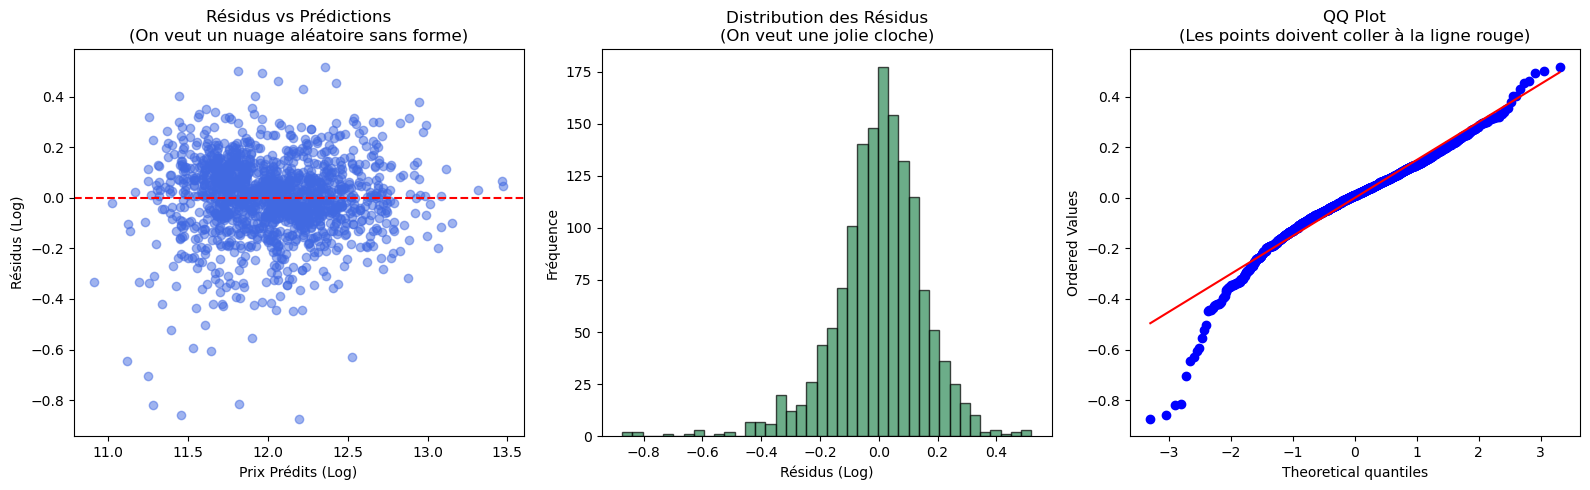

In [11]:
print("Analyse des résidus de la Baseline...")

# On utilise les prédictions générées par notre modèle déjà entraîné à l'étape 5
pred_train_log = baseline_pipeline.predict(X_train)

# Calcul des résidus sur l'échelle Logarithmique (celle utilisée par le modèle)
residuals_log = y_train_log - pred_train_log

# Statistiques basiques
print(f"Moyenne des résidus : {np.mean(residuals_log):.4f} (Idéalement proche de 0)")
print(f"Écart-type des résidus : {np.std(residuals_log):.4f}")

# Visualisation complète
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Résidus vs Prédictions (Vérification de l'homoscédasticité)
axes[0].scatter(pred_train_log, residuals_log, alpha=0.5, color='royalblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Prix Prédits (Log)')
axes[0].set_ylabel('Résidus (Log)')
axes[0].set_title('Résidus vs Prédictions\n(On veut un nuage aléatoire sans forme)')

# 2. Histogramme (Vérification de la normalité des erreurs)
axes[1].hist(residuals_log, bins=40, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('Résidus (Log)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des Résidus\n(On veut une jolie cloche)')

# 3. QQ-Plot (Vérification stricte de la normalité)
stats.probplot(residuals_log, dist="norm", plot=axes[2])
axes[2].set_title('QQ Plot\n(Les points doivent coller à la ligne rouge)')

plt.tight_layout()
plt.show()

# 11. Évaluation Finale : Les 3 Critères du Groupe
- **Mathématique (RMSE)** : Récupéré depuis la validation croisée (étape 7). C'est le RMSE sur l'échelle logarithmique, équivalent au RMSLE utilisé par Kaggle.
- **IT (Temps d'entraînement)** : Temps nécessaire pour entraîner le pipeline complet sur 100% du train set (preprocessing + modèle).
- **Métier (% d'écart médian)** : Médiane des écarts relatifs entre le prix prédit et le prix réel, en pourcentage. La médiane (plutôt que la moyenne) est choisie car elle est robuste aux valeurs extrêmes : elle représente l'erreur « typique » du modèle sur une maison standard.
- **Métier (Écart médian USD)** : Même indicateur exprimé en dollars, pour donner une idée concrète de l'erreur typique en valeur absolue.

  ÉVALUATION FINALE — MODÈLE M0 BASELINE
  Mathématique (RMSE Log) : 0.15739
  IT (Temps entraînement) : 0.03 secondes
  Métier (Écart médian)   : 8.36 %
  Métier (Écart médian USD): 13,999.72 $


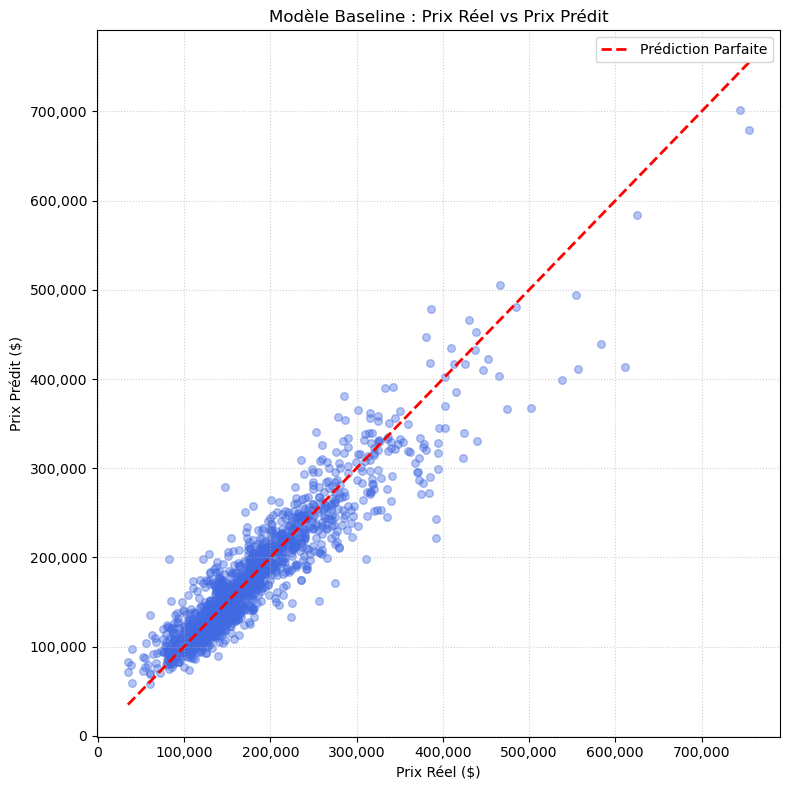

In [12]:
# 11. ÉVALUATION FINALE : LES 3 CRITÈRES DU GROUPE

import time
from sklearn.model_selection import cross_val_predict

# ── 1. MATHÉMATIQUE : RMSE (récupéré depuis l'étape 7) ──
# mean_rmse_cv a été calculé dans la cellule d'évaluation CV (cross_validate)
rmse_log = mean_rmse_cv

# ── 2. IT : Temps d'entraînement (un seul fit chronométré) ──
start_time = time.time()
baseline_pipeline.fit(X_train, y_train_log)
train_time = time.time() - start_time

# ── 3. MÉTIER : % d'écart médian (prédictions OOF honnêtes) ──
oof_pred_log = cross_val_predict(baseline_pipeline, X_train, y_train_log, cv=cv, n_jobs=-1)
oof_pred_price = np.expm1(oof_pred_log)
y_train_price = y_train  # y_train est déjà en dollars

# Écart relatif par maison : |prédit - réel| / réel * 100
ecart_pct = np.abs(oof_pred_price - y_train_price) / y_train_price * 100
ecart_median = np.median(ecart_pct)
ecart_median_usd = np.median(np.abs(oof_pred_price - y_train_price))

# ── AFFICHAGE ──
print("=" * 50)
print("  ÉVALUATION FINALE — MODÈLE M0 BASELINE")
print("=" * 50)
print(f"  Mathématique (RMSE Log) : {rmse_log:.5f}")
print(f"  IT (Temps entraînement) : {train_time:.2f} secondes")
print(f"  Métier (Écart médian)   : {ecart_median:.2f} %")
print(f"  Métier (Écart médian USD): {ecart_median_usd:,.2f} $")
print("=" * 50)

# ── GRAPHE : Prix Réel vs Prix Prédit ──
min_axis = min(y_train_price.min(), oof_pred_price.min())
max_axis = max(y_train_price.max(), oof_pred_price.max())

plt.figure(figsize=(8, 8))
plt.scatter(y_train_price, oof_pred_price, alpha=0.4, s=30, color="royalblue")
plt.plot([min_axis, max_axis], [min_axis, max_axis], color="red", linestyle="--", linewidth=2, label="Prédiction Parfaite")

formatter = plt.FuncFormatter(lambda x, p: format(int(x), ','))
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xlabel("Prix Réel ($)")
plt.ylabel("Prix Prédit ($)")
plt.title("Modèle Baseline : Prix Réel vs Prix Prédit")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## Suivi MLFlow
Ce bloc a été injecté automatiquement pour sauvegarder le modèle final dans MLFlow sans perturber le code existant.

In [ ]:
import mlflow
from mlflow.models import infer_signature

# --- MLFLOW CONFIG ---
mlflow.set_experiment("Ames_Housing_Baseline")
mlflow.set_tracking_uri("http://127.0.0.1:8080")


In [ ]:
print('Enregistrement du modèle dans MLFlow...')
with mlflow.start_run(run_name="Final_Model") as run:
    mlflow.log_metric("rmse_cv", rmse_log)
    mlflow.log_metric("training_time", train_time)
    mlflow.log_metric("ecart_median", ecart_median)
    mlflow.log_metric("ecart_moyen_dollars", ecart_median_usd)

    # Inférence de la signature
    signature = infer_signature(X_train, baseline_pipeline.predict(X_train))

    # Sauvegarde du pipeline Scikit-Learn
    mlflow.sklearn.log_model(
        sk_model=baseline_pipeline,
        signature=signature,
        input_example=X_train.head(3),
        registered_model_name="Ames_Housing_Baseline_Model",
        name="Ames_Housing_Baseline_model"
    )
print('Sauvegarde MLFlow terminée !')
